### Key terminology

#### Performance metrics
$reacall = sensitivity = \frac{true\,positive}{true\,positive + false\,negative}$ \
$precision = specificity = \frac{true\,negative}{true\,negative + false\,positive}$ \
$F_{score} = \frac{2}{reacall^{-1} + precision^{-1}}$

#### Leave one out
Train on n-1 and test on one removed element, then put back tested element and remove other element, train once again. Repeat until each of elements was excluded from training data. Finally average the results.

#### Reapeted random subsampling
Train-test split, reapeted for number of times.

#### Model (logistic function)
$p(x) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x)}}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_samples=1000000, n_features=3, n_redundant=0, 
                           n_informative=2, random_state=42, n_clusters_per_class=1)
X

array([[ 1.43113663,  1.19645372,  0.89751774],
       [-0.58338009, -0.07378017,  0.97959464],
       [ 1.21408538, -2.49381552,  0.82373695],
       ...,
       [ 0.79450965,  0.12441781,  1.08543501],
       [ 0.91434496, -0.13390393,  1.02604556],
       [-1.50011333,  0.4580567 ,  0.88953025]], shape=(1000000, 3))

In [3]:
# each feature has an assined weight to it (each veriable has a coefficient)\

# Model

p = lambda X, BETA: 1/(1+np.exp(-np.dot(X, BETA)))

In [4]:
cross_entropy = lambda X, y, BETA, eps = 1e-15: - np.mean(y*np.log(p(X, BETA) + eps) + (1 - y)*np.log(1 - p(X, BETA) + eps))

In [5]:
gradxe = lambda X, y, BETA: np.dot(X.T,(p(X, BETA) - y)) / X.shape[0]

In [6]:
def training_loop(X_train, y_train, X_test, y_test, B, num_epochs, lr, losses_train, losses_test, snapshot_interval):

    
    for epoch in range(num_epochs):
        

        if (epoch%snapshot_interval == 0):
            loss_train = cross_entropy(X_train, y_train, B)
            loss_test = cross_entropy(X_test, y_test, B)
            losses_train.append(loss_train)
            losses_test.append(loss_test)

            print(f'E {epoch}: training loss = {loss_train:.4f} | test loss = {loss_test:.4f}')


        grad = gradxe(X_train, y_train, B)
        B -= lr * grad

    return B

In [7]:
num_data = X.shape[0]
ones = np.ones((num_data, 1))
X = np.hstack((ones, X))
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, y_train = X[shuffle[:split]], y[shuffle[:split]]
X_test, y_test = X[shuffle[split:]], y[shuffle[split:]]

In [8]:
np.random.seed(42)
B = np.random.rand(X.shape[1])*10
losses_train=[]
losses_test=[]
snapshot_interval = 10
num_epochs=1000
lr=0.1
B = training_loop(X_train, y_train, 
                  X_test, y_test, 
                  B, 
                  num_epochs, 
                  lr, 
                  losses_train, 
                  losses_test, 
                  snapshot_interval)

E 0: training loss = 2.0998 | test loss = 2.0897
E 10: training loss = 1.9325 | test loss = 1.9232
E 20: training loss = 1.7826 | test loss = 1.7740
E 30: training loss = 1.6481 | test loss = 1.6402
E 40: training loss = 1.5274 | test loss = 1.5200
E 50: training loss = 1.4189 | test loss = 1.4121
E 60: training loss = 1.3212 | test loss = 1.3150
E 70: training loss = 1.2332 | test loss = 1.2276
E 80: training loss = 1.1538 | test loss = 1.1487
E 90: training loss = 1.0821 | test loss = 1.0774
E 100: training loss = 1.0172 | test loss = 1.0129
E 110: training loss = 0.9584 | test loss = 0.9545
E 120: training loss = 0.9050 | test loss = 0.9014
E 130: training loss = 0.8564 | test loss = 0.8531
E 140: training loss = 0.8122 | test loss = 0.8091
E 150: training loss = 0.7718 | test loss = 0.7690
E 160: training loss = 0.7348 | test loss = 0.7322
E 170: training loss = 0.7009 | test loss = 0.6986
E 180: training loss = 0.6698 | test loss = 0.6677
E 190: training loss = 0.6412 | test loss 

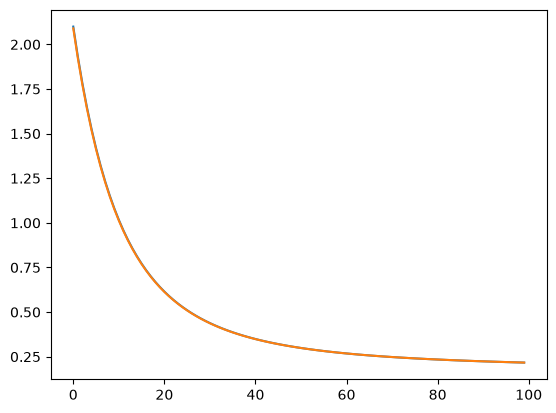

In [9]:
num_snaps = num_epochs // snapshot_interval
plt.plot(np.arange(num_snaps),losses_train)
plt.plot(np.arange(num_snaps),losses_test)